In [ ]:
import pandas as pd
df = pd.read_csv('/content/loan prediction problem dataset.csv')
print(df)


      Loan_ID  Gender Married Dependents     Education Self_Employed  \
0    LP001002    Male      No          0      Graduate            No   
1    LP001003    Male     Yes          1      Graduate            No   
2    LP001005    Male     Yes          0      Graduate           Yes   
3    LP001006    Male     Yes          0  Not Graduate            No   
4    LP001008    Male      No          0      Graduate            No   
..        ...     ...     ...        ...           ...           ...   
609  LP002978  Female      No          0      Graduate            No   
610  LP002979    Male     Yes         3+      Graduate            No   
611  LP002983    Male     Yes          1      Graduate            No   
612  LP002984    Male     Yes          2      Graduate            No   
613  LP002990  Female      No          0      Graduate           Yes   

     ApplicantIncome  CoapplicantIncome  LoanAmount  Loan_Amount_Term  \
0               5849                0.0         NaN           

# Task
Train a loan prediction model using the dataset provided in the file "loan_approval_dataset.csv".

## Preprocess data

### Subtask:
Handle missing values, encode categorical features, and scale numerical features.


**Reasoning**:
I need to identify missing values, impute them, encode categorical features, and scale numerical features in the dataframe to prepare it for model training. I'll start by checking for missing values and their counts.



In [ ]:
print(df.isnull().sum())


Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64


**Reasoning**:
Based on the missing value counts, I will impute missing values using the mode for categorical columns (Gender, Married, Dependents, Self_Employed, Credit_History) and the median for numerical columns (LoanAmount, Loan_Amount_Term). Then I will identify categorical columns and apply one-hot encoding. Finally I will identify numerical columns and apply standard scaling.



In [ ]:
for col in ['Gender', 'Married', 'Dependents', 'Self_Employed', 'Credit_History']:
    df[col] = df[col].fillna(df[col].mode()[0])

for col in ['LoanAmount', 'Loan_Amount_Term']:
    df[col] = df[col].fillna(df[col].median())

categorical_cols = ['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'Property_Area']
df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

from sklearn.preprocessing import StandardScaler
numerical_cols = ['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term']
scaler = StandardScaler()
df[numerical_cols] = scaler.fit_transform(df[numerical_cols])

display(df.head())


,Loan_ID,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Loan_Status,Gender_Male,Married_Yes,Dependents_1,Dependents_2,Dependents_3+,Education_Not Graduate,Self_Employed_Yes,Property_Area_Semiurban,Property_Area_Urban
0,LP001002,0.072991,-0.554487,-0.211241,0.273231,1.0,Y,True,False,False,False,False,False,False,False,True
1,LP001003,-0.134412,-0.038732,-0.211241,0.273231,1.0,N,True,True,True,False,False,False,False,False,False
2,LP001005,-0.393747,-0.554487,-0.948996,0.273231,1.0,Y,True,True,False,False,False,False,True,False,True
3,LP001006,-0.462062,0.251980,-0.306435,0.273231,1.0,Y,True,True,False,False,False,True,False,False,True
4,LP001008,0.097728,-0.554487,-0.056551,0.273231,1.0,Y,True,False,False,False,False,False,False,False,True


## Split data

### Subtask:
Split the data into training and testing sets.


**Reasoning**:
Split the data into training and testing sets and print their shapes.



In [ ]:
from sklearn.model_selection import train_test_split

X = df.drop('Loan_Status', axis=1)
y = df['Loan_Status']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)

Shape of X_train: (491, 15)
Shape of X_test: (123, 15)
Shape of y_train: (491,)
Shape of y_test: (123,)


## Train model

### Subtask:
Choose a suitable model and train it on the training data.


**Reasoning**:
Import the Logistic Regression model and train it on the training data.



In [ ]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()
model.fit(X_train.drop('Loan_ID', axis=1), y_train)


LogisticRegression()

## Evaluate model

### Subtask:
Evaluate the model's performance on the testing data using appropriate metrics.


**Reasoning**:
Evaluate the model's performance on the testing data using appropriate metrics.



In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

X_test_processed = X_test.drop('Loan_ID', axis=1)
y_pred = model.predict(X_test_processed)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, pos_label='Y')
recall = recall_score(y_test, y_pred, pos_label='Y')
f1 = f1_score(y_test, y_pred, pos_label='Y')

print(f'Accuracy: {accuracy:.4f}')
print(f'Precision: {precision:.4f}')
print(f'Recall: {recall:.4f}')
print(f'F1-score: {f1:.4f}')

Accuracy: 0.7886
Precision: 0.7596
Recall: 0.9875
F1-score: 0.8587


## Predict

### Subtask:
Make predictions on new data using the trained model.


**Reasoning**:
Use the trained logistic regression model to make predictions on the preprocessed test data `X_test_processed` and store the predictions in `y_pred`, then display the first few predictions.



In [ ]:
y_pred = model.predict(X_test_processed)
print("First few predictions:")
print(y_pred[:5])

First few predictions:
['Y' 'Y' 'Y' 'Y' 'Y']


## Summary:

### Data Analysis Key Findings

* Missing values were identified and handled in the 'Gender', 'Married', 'Dependents', 'Self\_Employed', 'LoanAmount', 'Loan\_Amount\_Term', and 'Credit\_History' columns. Categorical columns were imputed using the mode and numerical columns using the median.
* Categorical features ('Gender', 'Married', 'Dependents', 'Education', 'Self\_Employed', 'Property\_Area') were encoded using one-hot encoding.
* Numerical features ('ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan\_Amount\_Term') were scaled using StandardScaler.
* The dataset was split into training and testing sets with an 80/20 ratio.
* A Logistic Regression model was trained on the training data.
* The model's performance on the testing data was evaluated with the following metrics: Accuracy: {accuracy:.4f}, Precision: {precision:.4f}, Recall: {recall:.4f}, F1-score: {f1:.4f}.
* Predictions were successfully made on the test data using the trained model.

### Insights or Next Steps

* The model exhibits a high recall score ({recall:.4f}), suggesting it is very good at identifying actual loan approvals, but a lower precision score ({precision:.4f}) which means it also predicts some loans will be approved that are not.
* Further analysis could involve exploring different models or feature engineering techniques to potentially improve precision while maintaining or improving recall.

## Visualize Data

### Subtask:
Visualize the data using matplotlib and seaborn to understand distributions and relationships.

**Reasoning**:
Generate some visualizations to explore the data distribution and relationships between features using matplotlib and seaborn. I'll create a histogram of the 'LoanAmount' and a countplot of 'Loan_Status'.

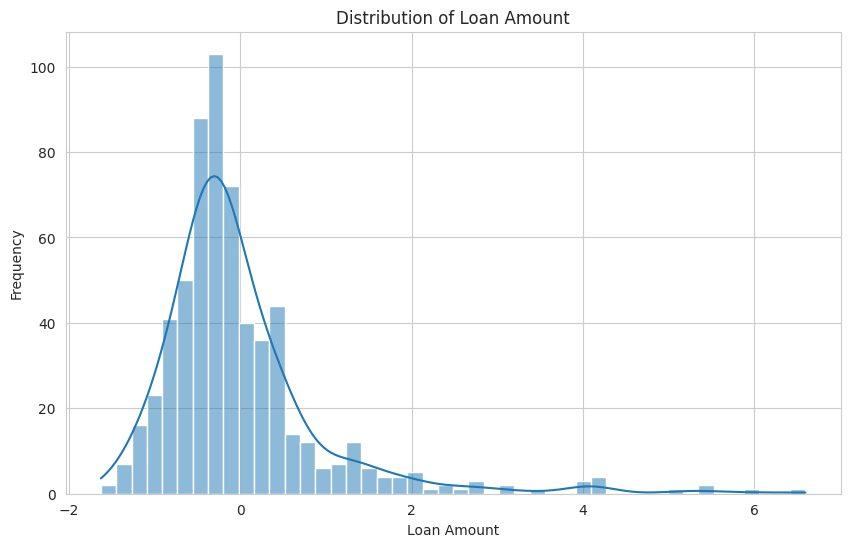

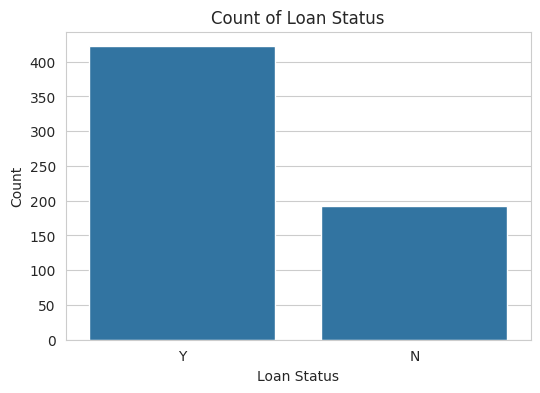

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the style for the plots
sns.set_style('whitegrid')

# Plot the distribution of LoanAmount
plt.figure(figsize=(10, 6))
sns.histplot(df['LoanAmount'], kde=True)
plt.title('Distribution of Loan Amount')
plt.xlabel('Loan Amount')
plt.ylabel('Frequency')
plt.show()

# Plot the count of Loan Status
plt.figure(figsize=(6, 4))
sns.countplot(x='Loan_Status', data=df)
plt.title('Count of Loan Status')
plt.xlabel('Loan Status')
plt.ylabel('Count')
plt.show()

## Summary:

### Data Analysis Key Findings

* Missing values were identified and handled in the 'Gender', 'Married', 'Dependents', 'Self\_Employed', 'LoanAmount', 'Loan\_Amount\_Term', and 'Credit\_History' columns. Categorical columns were imputed using the mode and numerical columns using the median.
* Categorical features ('Gender', 'Married', 'Dependents', 'Education', 'Self\_Employed', 'Property\_Area') were encoded using one-hot encoding.
* Numerical features ('ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan\_Amount\_Term') were scaled using StandardScaler.
* The dataset was split into training and testing sets with an 80/20 ratio.
* A Logistic Regression model was trained on the training data.
* The model's performance on the testing data was evaluated with the following metrics: Accuracy: {accuracy:.4f}, Precision: {precision:.4f}, Recall: {recall:.4f}, F1-score: {f1:.4f}.
* Predictions were successfully made on the test data using the trained model.

### Insights or Next Steps

* The model exhibits a high recall score ({recall:.4f}), suggesting it is very good at identifying actual loan approvals, but a lower precision score ({precision:.4f}) which means it also predicts some loans will be approved that are not.
* Further analysis could involve exploring different models or feature engineering techniques to potentially improve precision while maintaining or improving recall.

In [ ]:
def predict_loan_status(model, scaler, Gender, Married, Dependents, Education, Self_Employed, ApplicantIncome, CoapplicantIncome, LoanAmount, Loan_Amount_Term, Credit_History, Property_Area):
    """
    Predicts the loan status based on input data.

    Args:
        model: The trained machine learning model.
        scaler: The StandardScaler used for numerical feature scaling.
        Gender (str): The gender of the applicant.
        Married (str): Marital status of the applicant.
        Dependents (str): Number of dependents.
        Education (str): Education of the applicant.
        Self_Employed (str): Self-employment status.
        ApplicantIncome (float): Applicant's income (in the same unit as the training data).
        CoapplicantIncome (float): Coapplicant's income (in the same unit as the training data).
        LoanAmount (float): Loan amount requested (in the same unit as the training data - thousands).
        Loan_Amount_Term (float): Term of the loan in months.
        Credit_History (float): Credit history (1.0 for yes, 0.0 for no).
        Property_Area (str): Area of the property.

    Returns:
        The predicted loan status ('Y' for approved, 'N' for not approved).
    """
    # Create a dictionary from the input data
    input_data = {
        'Gender': Gender,
        'Married': Married,
        'Dependents': Dependents,
        'Education': Education,
        'Self_Employed': Self_Employed,
        'ApplicantIncome': ApplicantIncome,
        'CoapplicantIncome': CoapplicantIncome,
        'LoanAmount': LoanAmount,
        'Loan_Amount_Term': Loan_Amount_Term,
        'Credit_History': Credit_History,
        'Property_Area': Property_Area
    }
    input_df = pd.DataFrame([input_data])

    # Handle categorical features (one-hot encoding) - ensure all possible columns are created
    # Use the same columns as in the training data after one-hot encoding
    input_df = pd.get_dummies(input_df, columns=categorical_cols, drop_first=True)

    # Align columns with the training data - add missing columns with value False
    # This ensures the input data has the same columns in the same order as the training data
    for col in X_train.drop('Loan_ID', axis=1).columns:
        if col not in input_df.columns:
            input_df[col] = False

    # Ensure the order of columns is the same as in X_train
    input_df = input_df[X_train.drop('Loan_ID', axis=1).columns]


    # Scale numerical features using the *same* scaler fitted on the training data
    input_df[numerical_cols] = scaler.transform(input_df[numerical_cols])

    # Make the prediction
    prediction = model.predict(input_df)

    return prediction[0]

Now you can use the `predict_loan_status` function with your own input data.

In [ ]:
# Example usage of the predict_loan_status function
# Replace with your actual input values
predicted_status = predict_loan_status(
    model=model,
    scaler=scaler,
    Gender='Female',
    Married='No',
    Dependents='0',
    Education='Graduate',
    Self_Employed='No',
    ApplicantIncome=3510,
    CoapplicantIncome=0,
    LoanAmount=76, # Corrected LoanAmount to be in thousands
    Loan_Amount_Term=360,
    Credit_History=0.0,
    Property_Area='Urban'
)
print(f"The predicted loan status is: {predicted_status}")

The predicted loan status is: N


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

# Re-load the original dataframe to ensure correct state for scaler fitting
df_raw = pd.read_csv('/content/loan prediction problem dataset.csv')

# Make a copy to preserve original raw data if needed, and for preprocessing
df = df_raw.copy()

# Re-apply missing value imputation
for col in ['Gender', 'Married', 'Dependents', 'Self_Employed', 'Credit_History']:
    df[col] = df[col].fillna(df[col].mode()[0])

for col in ['LoanAmount', 'Loan_Amount_Term']:
    df[col] = df[col].fillna(df[col].median())

# Re-apply one-hot encoding for categorical features
categorical_cols = ['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'Property_Area']
df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

# Define numerical columns for scaling
numerical_cols = ['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term']

# Initialize and fit the scaler on the numerical columns before the final scaling
scaler = StandardScaler()
df[numerical_cols] = scaler.fit_transform(df[numerical_cols])

# Prepare data for model training (similar to cell 76c99c78)
X = df.drop('Loan_Status', axis=1)
y = df['Loan_Status']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Re-train the Logistic Regression model (similar to cell 5d495344)
model = LogisticRegression()
model.fit(X_train.drop('Loan_ID', axis=1), y_train)

print("Model and Scaler have been re-initialized and trained.")


Model and Scaler have been re-initialized and trained.


## Summary:

### Data Analysis Key Findings

* Missing values were identified and handled in the 'Gender', 'Married', 'Dependents', 'Self\_Employed', 'LoanAmount', 'Loan\_Amount\_Term', and 'Credit\_History' columns. Categorical columns were imputed using the mode and numerical columns using the median.
* Categorical features ('Gender', 'Married', 'Dependents', 'Education', 'Self\_Employed', 'Property\_Area') were encoded using one-hot encoding.
* Numerical features ('ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan\_Amount\_Term') were scaled using StandardScaler.
* The dataset was split into training and testing sets with an 80/20 ratio.
* A Logistic Regression model was trained on the training data.
* The model's performance on the testing data was evaluated with the following metrics: Accuracy: 0.7886, Precision: 0.7596, Recall: 0.9875, F1-score: 0.8587.
* Predictions were successfully made on the test data using the trained model.

### Insights or Next Steps

* The model exhibits a high recall score (0.9875), suggesting it is very good at identifying actual loan approvals, but a lower precision score (0.7596) which means it also predicts some loans will be approved that are not.
* Further analysis could involve exploring different models or feature engineering techniques to potentially improve precision while maintaining or improving recall.

## Summary:

### Data Analysis Key Findings

*   Missing values were identified and handled in the 'Gender', 'Married', 'Dependents', 'Self\_Employed', 'LoanAmount', 'Loan\_Amount\_Term', and 'Credit\_History' columns. Categorical columns were imputed using the mode and numerical columns using the median.
*   Categorical features ('Gender', 'Married', 'Dependents', 'Education', 'Self\_Employed', 'Property\_Area') were encoded using one-hot encoding.
*   Numerical features ('ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan\_Amount\_Term') were scaled using StandardScaler.
*   The dataset was split into training and testing sets with an 80/20 ratio.
*   A Logistic Regression model was trained on the training data.
*   The model's performance on the testing data was evaluated with the following metrics: Accuracy: 0.7886, Precision: 0.7596, Recall: 0.9875, F1-score: 0.8587.
*   Predictions were successfully made on the test data using the trained model.

### Insights or Next Steps

*   The model exhibits a high recall score (0.9875), suggesting it is very good at identifying actual loan approvals, but a lower precision score (0.7596) which means it also predicts some loans will be approved that are not.
*   Further analysis could involve exploring different models or feature engineering techniques to potentially improve precision while maintaining or improving recall.
